# Small Image Classification Using Convolutional Neural Network (CNN)
In this notebook, we will classify small images cifar10 dataset from tensorflow keras datasets. There are total 10 classes as shown below. We will use CNN for classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers,models,datasets

In [2]:
(X_train,y_train),(X_test,y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 856s 5us/step


In [3]:
X_test.shape

(10000, 32, 32, 3)

In [4]:
y_train.shape


(50000, 1)

In [5]:
y_train[:5]
# y_train is the label of the image and it is in the form of a 2D array. We need to convert it to a 1D array.
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

In [6]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [7]:
# Let's plot some images to see what they are
def plot_sample(X,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

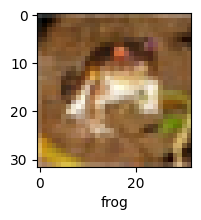

In [8]:
plot_sample(X_train, y_train, 0)

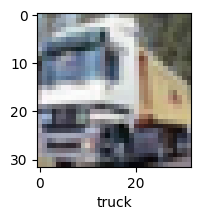

In [9]:
plot_sample(X_train, y_train, 1)

# Normalizing the training data

In [10]:
# Normalize the images to a number from 0 to 1. Image has 3 channels (R,G,B) and each value in the channel can range from 0 to 255. Hence to normalize in 0-->1 range, we need to divide it by 255
X_train = X_train / 255.0
X_test = X_test / 255.0

In [11]:

# 🔹 What is Softmax Activation?

# Softmax converts raw output values (logits) into probabilities.

# It ensures:

# All output values are between 0 and 1

# The sum of all outputs = 1

# So the output can be interpreted as probabilities of different classes.

*Build simple artificial neural network for image classification*

In [15]:
ann=models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000,activation="relu"),
    layers.Dense(1000,activation="relu"),
    layers.Dense(10,activation="softmax")
])
ann.compile(optimizer="SGD",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

ann.fit(X_train,y_train,epochs=5)

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 113s 71ms/step - accuracy: 0.3544 - loss: 1.8142
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 0.4277 - loss: 1.6242
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 119s 76ms/step - accuracy: 0.4554 - loss: 1.5420
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 77ms/step - accuracy: 0.4799 - loss: 1.4819
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 55ms/step - accuracy: 0.4961 - loss: 1.4304


In [16]:
from sklearn.metrics import confusion_matrix,classification_report
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(i) for i in y_pred]
print("classification report :\n",classification_report(y_test,y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
classification report :
               precision    recall  f1-score   support

           0       0.55      0.47      0.51      1000
           1       0.63      0.55      0.59      1000
           2       0.34      0.28      0.31      1000
           3       0.40      0.18      0.25      1000
           4       0.45      0.19      0.27      1000
           5       0.52      0.21      0.30      1000
           6       0.24      0.91      0.38      1000
           7       0.80      0.25      0.38      1000
           8       0.44      0.78      0.56      1000
           9       0.74      0.27      0.40      1000

    accuracy                           0.41     10000
   macro avg       0.51      0.41      0.39     10000
weighted avg       0.51      0.41      0.39     10000



# Now let us build a convolutional neural network to train our images

In [18]:
cnn=models.Sequential([
    layers.Conv2D(filters=32,kernel_size=(3,3),activation="relu",input_shape=(32,32,3)),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=64,kernel_size=(3,3),activation="relu"),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation="relu"),  
    layers.Dense(10,activation="softmax")
])

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
cnn.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
cnn.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.4705 - loss: 1.4785
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.6044 - loss: 1.1283
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6566 - loss: 0.9839
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.6844 - loss: 0.9045
Epoch 5/5


With CNN, at the end 5 epochs, accuracy was at around 70% which is a significant improvement over ANN. CNN's are best for image classification and gives superb accuracy. Also computation is much less compared to simple ANN as maxpooling reduces the image dimensions while still preserving the features

In [ ]:
cnn.evaluate(X_test,y_test)

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

In [ ]:
y_test[:5]

In [ ]:
plot_sample(X_test, y_test,3)

In [ ]:
classes[y_classes[3]]

In [ ]:
# model = keras.Sequential([
    
#     layers.Conv2D(30, (3,3), activation='relu', input_shape=(28, 28, 1)),
#     layers.MaxPooling2D((2,2)),
 
#     layers.Flatten(),
#     layers.Dense(100, activation='relu'),
#     keras.layers.Dense(10, activation='sigmoid')
# ])    for handwritten digit recognition dataset MNIST, input shape is (28,28,1) because the images are 28x28 pixels and they are grayscale (1 channel). But for CIFAR10 dataset, the images are 32x32 pixels and they are colored (3 channels - R,G,B), hence input shape is (32,32,3)